In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import os
import random


import numpy as np
from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor,LinearRegression

In [3]:
fontsize = 16
fontsize_minor = 12


/tmp/ipykernel_495002/517125019.py:16: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/517125019.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/517125019.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


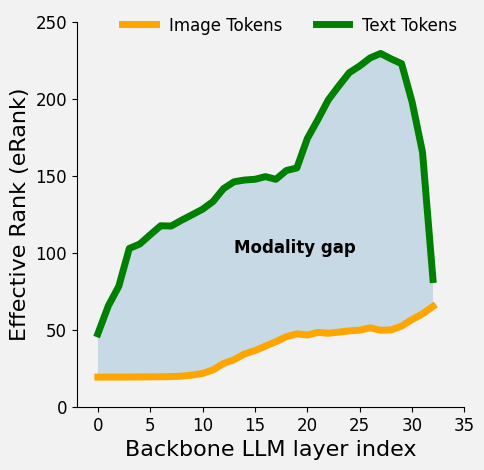

In [334]:
### gap illustartion
fig,ax = plt.subplots(1,1,figsize=(5,5))
ax=[ax]
model = 'llava-v1.6-mistral-7b',

path = '../../results/llava-v1.6-mistral-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv'

df = pd.read_csv(path, index_col=0).reset_index(names="sample")
df = df[df['sample']==0]
df = df.drop(['sample'],axis=1)

df = df.melt(['Mean over','contains'])
df['layers'] = df['variable'].astype(int)
    
    
b = sns.lineplot(
    data=df[
        (df['Mean over']!='All tokens') 
        & (df['Mean over']!='Image only tokens')
        & (df['Mean over']!='Text only tokens')
    ],
    # data=plot_df,
    x='layers',
    y='value',
    hue='Mean over',
    palette=['orange','green', 'lightgreen', 'red'],
    err_style='bars',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax[0],
    linewidth=5
)


# --- choose the two curves you want to fill between ---
curve_a = "Img tokens"   # <-- replace with exact label in df['Mean over']
curve_b = "Text tokens"     # <-- replace with exact label in df['Mean over']

sub = df[
    (df['Mean over'] != 'Image only tokens') &
    (df['Mean over'] != 'Text only tokens')
].copy()

# pivot so each curve becomes a column, aligned by layer
wide = (sub[sub["Mean over"].isin([curve_a, curve_b])]
        .pivot_table(index="layers", columns="Mean over", values="value", aggfunc="mean")
        .sort_index())

x = wide.index.to_numpy()
y1 = wide[curve_a].to_numpy()
y2 = wide[curve_b].to_numpy()

# fill between the two curves
ax[0].fill_between(x, y1, y2, alpha=0.2)

# # --- Set other parameters ---

b.set(ylim=(0,250), xlim=(-2,35))
    
b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
b.set_ylabel('Effective Rank (eRank)', fontsize=fontsize)
b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.legend(
    labels=['Image Tokens', 'Text Tokens'],
    loc=(0.1,0.95),
    ncols=2,
    frameon=False, 
    fontsize=fontsize_minor,
    
)

b.text(
    x=13,
    y=100,
    s="Modality gap",
    fontweight='bold',
    fontsize=fontsize_minor
)


plt.subplots_adjust(wspace=0.3)
sns.despine(top=True, right=True)
# ax[1].set_facecolor((0.95, 0.95, 0.95))
ax[0].set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure


# ax[1].annotate(
#         (
#             "Performance decreases\nas gap increases" 
#         # "Effective rank differences suggest\n" 
#         # "that text and vision tokens\n"
#         # "may utilize the shared\n"
#         # "representation space differently,\n"
#         # "leading to unequal contributions\n"
#         # "to downstream reasoning."
#     ),
#     xy=(120, 0.35),
#     xytext=(120,0.7),
#     arrowprops=dict(
#         arrowstyle="->", 
#         linewidth=1,
#         connectionstyle="arc3,rad=0" ,
#         relpos=(0.5, 0.5)
#     ),
#     fontsize=12,
#     fontweight=299,
#     ha="center",
#     va="center",
# )

fig.savefig(
    "./../Figures/gap_illustration_single.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)




/tmp/ipykernel_495002/2824928864.py:31: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2824928864.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2824928864.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_495002/2824928864.py:31: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2824928864.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2824928864.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

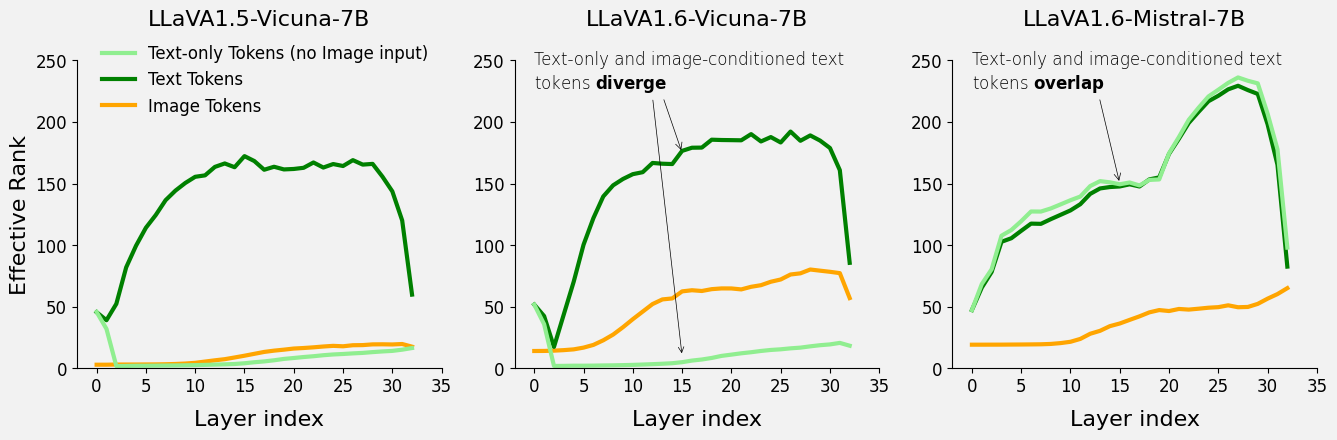

In [257]:
### gap illustartion
fig, ax = plt.subplots(1,3,figsize=(16,4))

model_ls = [
    'LLaVA1.5-Vicuna-7B',
    'LLaVA1.6-Vicuna-7B',
    'LLaVA1.6-Mistral-7B',
]

paths = [
    '../../results/llava-1.5-7b/svd/token/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
    '../../results/llava-v1.6-vicuna-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
    '../../results/llava-v1.6-mistral-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
]

backbone_ls = [
    'LLaVA1.5-Vicuna-7B',
    'LLaVA1.6-Vicuna-7B',
    'LLaVA1.6-Mistral-7B',
]


for idx, path in enumerate(paths):
    df = pd.read_csv(path, index_col=0)
    if 'sample' not in df.columns:
        df = df.reset_index(names="sample" if 'sample' not in df.columns else 'Unnamed')
    df = df[df['sample']==0]
    
    df = df.drop(['sample'],axis=1) if 'label' not in df.columns else df.drop(['sample','label'],axis=1)
    
    df = df.melt(['Mean over','contains'])
    df['layers'] = df['variable'].astype(int)
        
        
    b = sns.lineplot(
        data=df[
            (df['Mean over']!='All tokens') 
            & (df['Mean over']!='Image only tokens')
            # & (df['Mean over']!='Text only tokens')
        ],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        err_style='bars',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[idx],
        linewidth=3
    )
    
    
    b.set(ylim=(0,250), xlim=(-2,35))
    b.set_title(
        model_ls[idx],
        pad=25,
        fontsize=fontsize,
    )
    
    b.set_xlabel(f'Layer index', labelpad=10, fontsize=fontsize)
    if idx==0:
        b.set_ylabel('Effective Rank', fontsize=fontsize)
    else:
        b.set_ylabel('', fontsize=fontsize)
        
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    handles, labels = b.get_legend_handles_labels()
    
    order = [
        'Text only tokens',
        'Text tokens',
        'Img tokens',
    ]
    
    label_map = {
        'Text only tokens': 'Text-only Tokens (no Image input)',
        'Text tokens': 'Text Tokens',
        'Img tokens': 'Image Tokens',
    }
    
    # reorder handles and relabel
    handles = [handles[labels.index(o)] for o in order]
    labels  = [label_map[o] for o in order]

    if idx==0:
        b.legend(
            handles,
            labels,
            loc=(0.05,0.8),
            ncols=1,
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()

    if idx==1:
        ax[idx].annotate(
            text=(
                "Text-only and image-conditioned text\n"
                r"tokens $\bf{diverge}$"
            ),
            xy=(15, 175),          # between the two curves
            xytext=(0, 240),
            arrowprops=dict(
                arrowstyle="->", 
                lw=0.5,
                relpos=(0.4, 0.25), 
            ),
            ha="left",
            va="center",
            fontsize=12,
            fontweight=299,
        )

        ax[idx].annotate(
            "",
            xy=(15, 10),
            xytext=(12, 220),
            arrowprops=dict(
                arrowstyle="->",
                lw=0.5,
                connectionstyle="arc3,rad=0",
                relpos=(0.4, 0.25), 
            ),
        )

    if idx==2:
        ax[idx].annotate(
            text=(
                "Text-only and image-conditioned text\n"
                r"tokens $\bf{overlap}$"
            ),
            xy=(15, 150),          # overlapping region
            xytext=(0, 240),
            arrowprops=dict(
                arrowstyle="->", 
                lw=0.5,
                relpos=(0.4, 0.25), 
            ),
            fontsize=12,
            fontweight=299,
            ha="left",
            va="center",
        )

    ax[idx].set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure


sns.despine(top=True, right=True)



fig.savefig(
    "./../Figures/vicuna_vs_mistral.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)




Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', 'Mean over'],
      dtype='object')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', 'Mean over'],
      dtype='object')


/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', 'Mean over'],
      dtype='object')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', 'Mean over'],
      dtype='object')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       'Mean over'],
      dtype='object')


/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', 'Mean over'],
      dtype='object')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       'Mean over'],
      dtype='object')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       'Mean over'],
      dtype='object')


/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_495002/2184375837.py:42: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/2184375837.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/2184375837.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

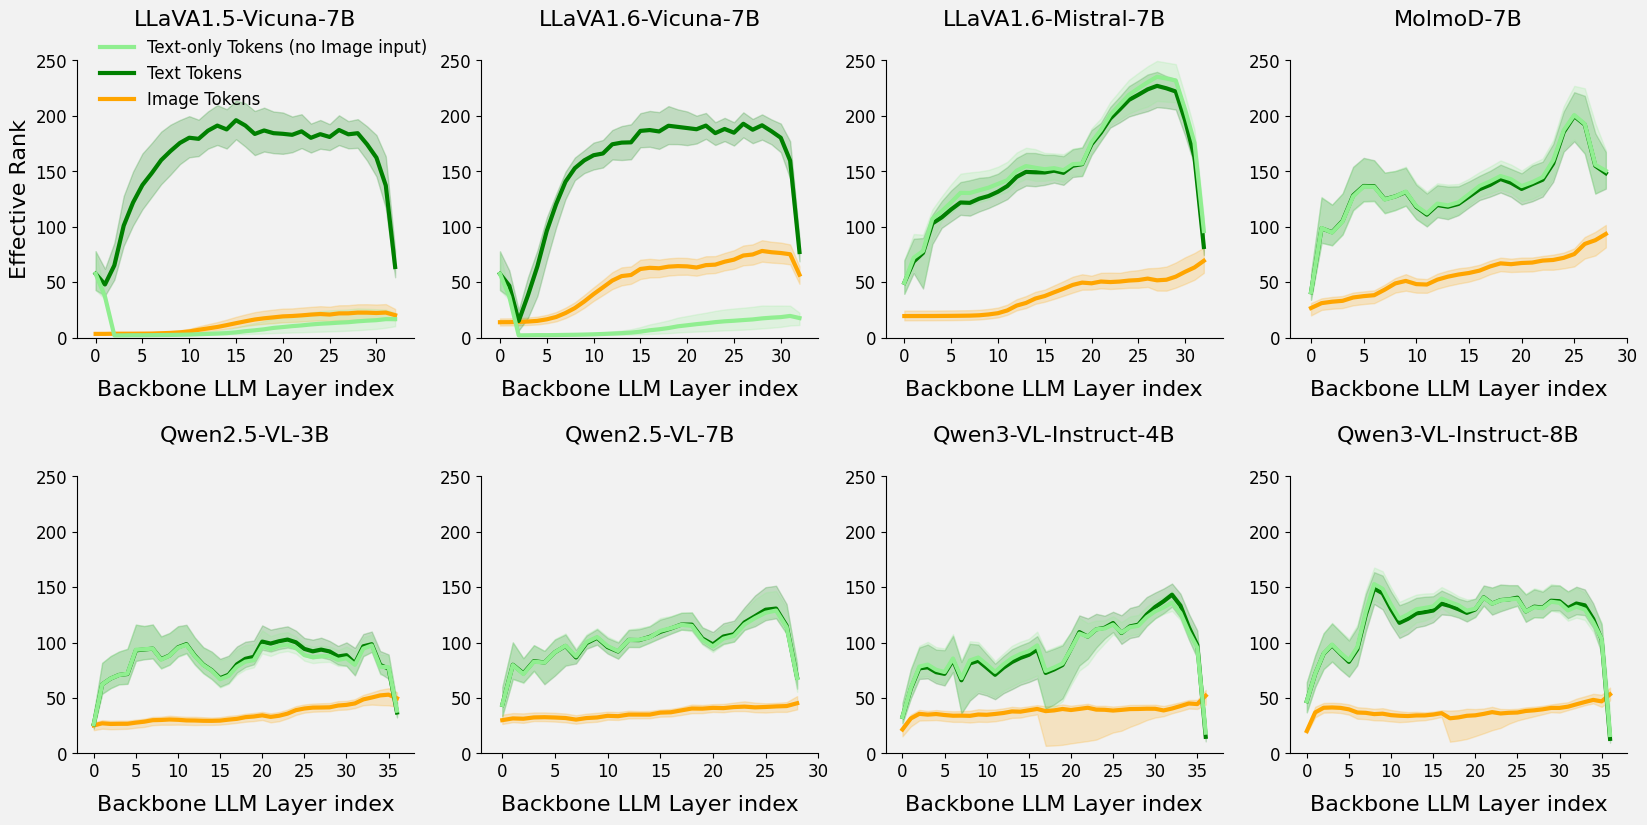

In [343]:
### gap illustartion
fig, ax = plt.subplots(2,4,figsize=(20,9))
ax = ax.flatten()

model_ls = [
    'LLaVA1.5-Vicuna-7B',
    'LLaVA1.6-Vicuna-7B',
    'LLaVA1.6-Mistral-7B',
    'MolmoD-7B',
    'Qwen2.5-VL-3B',
    'Qwen2.5-VL-7B',
    'Qwen3-VL-Instruct-4B',
    'Qwen3-VL-Instruct-8B',
]

paths = [
    '../../results/llava-1.5-7b/svd//MATE_svd_effective_rank_corrected.csv',
    '../../results/llava-v1.6-vicuna-7b/svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/llava-v1.6-mistral-7b/svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/molmoD-7B//svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/Qwen2.5-VL-3B//svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/Qwen2.5-VL-7B/svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct//svd/MATE_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-8B-Instruct/svd/MATE_svd_effective_rank_corrected.csv',
]

for idx, path in enumerate(paths):
    df = pd.read_csv(path, index_col=0)
    if 'sample' not in df.columns:
        df = df.reset_index(names="sample" if 'sample' not in df.columns else 'Unnamed')
    # df = df[df['sample'].isin([0,1,2,3,4,5])]
    embedding_cols = [c for c in df.columns if c.isdigit()]
    df = df[embedding_cols+['Mean over']]
    
    # df = df.drop(['sample'],axis=1) if 'label' not in df.columns else df.drop(['sample','label'],axis=1)
     
    print(df.columns)
    df = df.melt(['Mean over'])
    df['layers'] = df['variable'].astype(int)
    
        
    b = sns.lineplot(
        data=df[
            (df['Mean over']!='All tokens') 
            & (df['Mean over']!='Image only tokens')
            # & (df['Mean over']!='Text only tokens')
        ],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        # err_style='bars',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[idx],
        linewidth=3
    )
    
    
    b.set(ylim=(0,250), xlim=(-2,len(embedding_cols)+1))
    b.set_title(
        model_ls[idx],
        pad=25,
        fontsize=fontsize,
    )
    
    b.set_xlabel(f'Backbone LLM Layer index', labelpad=10, fontsize=fontsize)
    if idx==0:
        b.set_ylabel('Effective Rank', fontsize=fontsize)
    else:
        b.set_ylabel('', fontsize=fontsize)
        
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    handles, labels = b.get_legend_handles_labels()
    
    order = [
        'Text only tokens',
        'Text tokens',
        'Img tokens',
    ]
    
    label_map = {
        'Text only tokens': 'Text-only Tokens (no Image input)',
        'Text tokens': 'Text Tokens',
        'Img tokens': 'Image Tokens',
    }
    
    # reorder handles and relabel
    handles = [handles[labels.index(o)] for o in order]
    labels  = [label_map[o] for o in order]

    if idx==0:
        b.legend(
            handles,
            labels,
            loc=(0.05,0.8),
            ncols=1,
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()

    ax[idx].set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure

plt.subplots_adjust(hspace=0.5)

sns.despine(top=True, right=True)



fig.savefig(
    "./../Figures/gaps_models_MATE.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)




/tmp/ipykernel_495002/595938972.py:47: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/595938972.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/595938972.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_495002/595938972.py:47: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_495002/595938972.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_495002/595938972.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

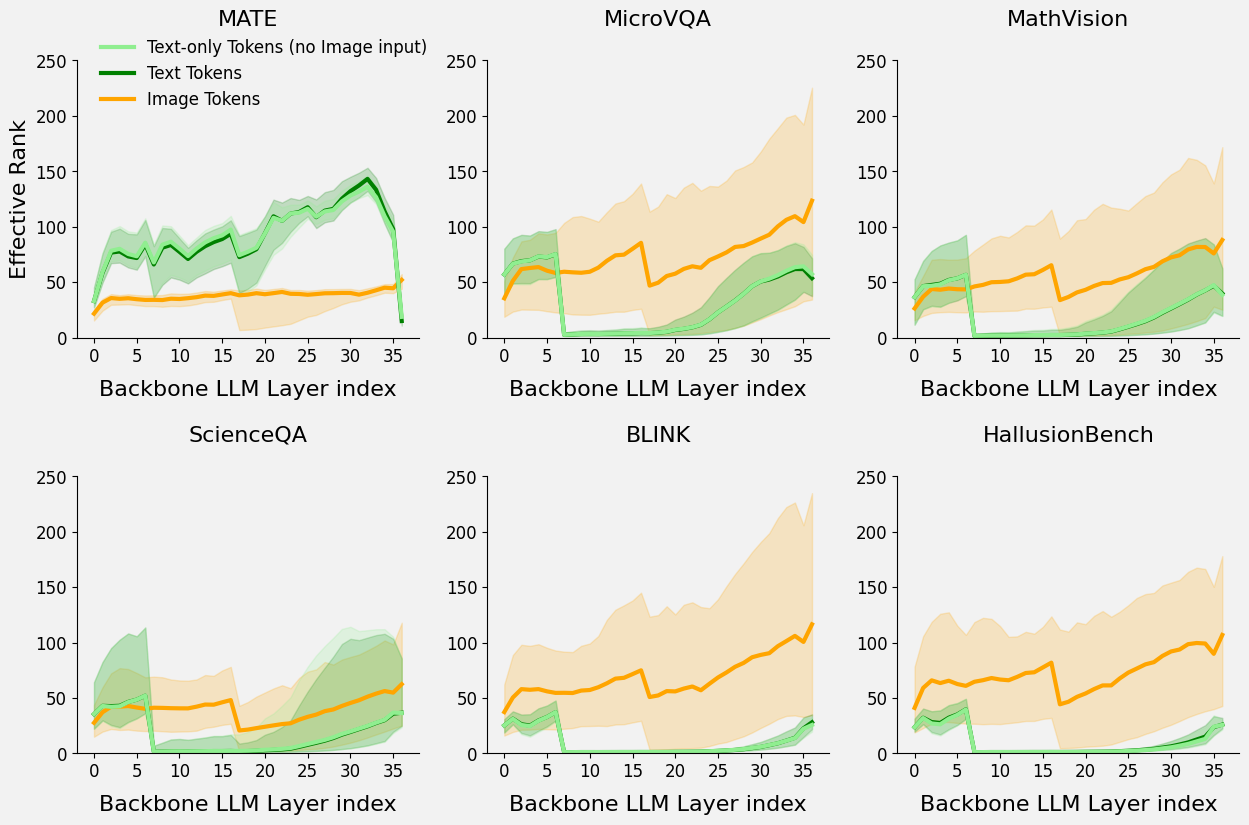

In [358]:
### gap illustartion
fig, ax = plt.subplots(2,3,figsize=(15,9))
ax = ax.flatten()

ds_ls = [
    'MATE',
    'MicroVQA',
    'MathVision',
    'ScienceQA',
    'BLINK',
    'HallusionBench'  
]

# accuracy_dict = {
#     'MATE': 0.34,
#     'MicroVQA': 0.24,
#     'MathVision': 0.28,
#     'ScienceQA': 0.48,
#     'BLINK': 0.48,
#     'HallusionBench': 0.56 
# }

paths = [
    '../../results/Qwen3-VL-4B-Instruct//svd//MATE_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct//svd/MicroVQA_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct///svd/MathVision_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct//svd/ScienceQA_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct///svd/BLINK_svd_effective_rank_corrected.csv',
    '../../results/Qwen3-VL-4B-Instruct//svd/HallusionBench_svd_effective_rank_corrected.csv',
]


for idx, path in enumerate(paths):
    df = pd.read_csv(path, index_col=0)
    if 'sample' not in df.columns:
        df = df.reset_index(names="sample" if 'sample' not in df.columns else 'Unnamed')
    # df = df[df['sample'].isin([0,1,2,3,4,5])]
    embedding_cols = [c for c in df.columns if c.isdigit()]
    df = df[embedding_cols+['Mean over']]
    
    # df = df.drop(['sample'],axis=1) if 'label' not in df.columns else df.drop(['sample','label'],axis=1)
     
    df = df.melt(['Mean over'])
    df['layers'] = df['variable'].astype(int)
    
        
    b = sns.lineplot(
        data=df[
            (df['Mean over']!='All tokens') 
            & (df['Mean over']!='Image only tokens')
            # & (df['Mean over']!='Text only tokens')
        ],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        # err_style='bars',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[idx],
        linewidth=3
    )
    
    
    b.set(ylim=(0,250), xlim=(-2,len(embedding_cols)+1))
    b.set_title(
        f"{ds_ls[idx]}",
        pad=25,
        fontsize=fontsize,
    )
    
    b.set_xlabel(f'Backbone LLM Layer index', labelpad=10, fontsize=fontsize)
    if idx==0:
        b.set_ylabel('Effective Rank', fontsize=fontsize)
    else:
        b.set_ylabel('', fontsize=fontsize)
        
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    handles, labels = b.get_legend_handles_labels()
    
    order = [
        'Text only tokens',
        'Text tokens',
        'Img tokens',
    ]
    
    label_map = {
        'Text only tokens': 'Text-only Tokens (no Image input)',
        'Text tokens': 'Text Tokens',
        'Img tokens': 'Image Tokens',
    }
    
    # reorder handles and relabel
    handles = [handles[labels.index(o)] for o in order]
    labels  = [label_map[o] for o in order]

    if idx==0:
        b.legend(
            handles,
            labels,
            loc=(0.05,0.8),
            ncols=1,
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()

    ax[idx].set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure

plt.subplots_adjust(hspace=0.5)

sns.despine(top=True, right=True)



# fig.savefig(
#     "./../Figures/gaps_models_MATE.png",
#     dpi=300,
#     # transparent=True,
#     bbox_inches="tight"
# )




# llava-v1.6-mistral-7b	BLINK	0.48	-86.383646
# HallusionBench	0.56	-66.726752
# MATE	0.34	12.499478
# MathVision	0.28	-33.116755
# MicroVQA	0.24	-52.736275
# ScienceQA	0.48	-62.310002
# VstarBench	0.60	-112.502553

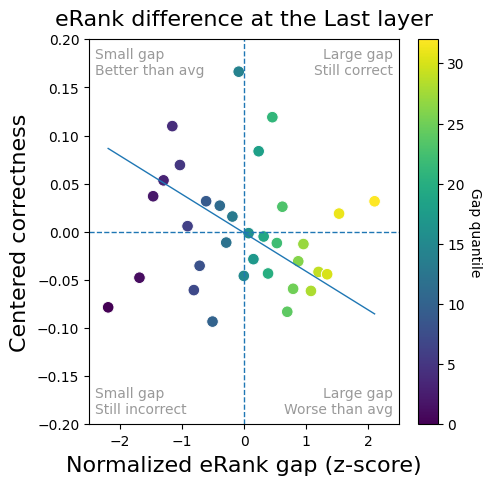

In [81]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

# fig, axes = plt.subplots(nrows=len(model_ls), ncols=1, figsize=(7.5, 20))
# axes = axes.flatten()

# lastns = [0, 5, 11, 15, 20, -5, -3, -1]
lastns = [-1]
# lastns = [0]
# title_mapper = {
#     0: '1st layer',
#     5: '5th layer',
#     11: '11th layer',
#     15: '15th layer',
#     20: '20th layer',
#     -5: '5th last layer',
#     -3: '3rd last layer',
#     -1: 'Last layer',
# }

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax = [ax]

for i, lastn in enumerate(lastns):
    total_df = []
    for idx, model_name in enumerate(model_ls):
        plot_df = []
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
                pass
            elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
                pass
            elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
    
                if ds_name=='MATE':
                    df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]
    
                # create prediction correct or not column
                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                
                embedding_cols = [c for c in df.columns if c.isdigit()]
                
                embedding_cols = embedding_cols[lastn]
                
                # plot x and y
                # print(embedding_cols, len(embedding_cols))
                
                y = df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                    df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy()
                # y = np.abs(y)
                
                # plot x and y
                x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
                
                plot_df_ds = pd.DataFrame({
                    'Prediction':x,
                    'eRank_diff':y,
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
                total_df = total_df + [plot_df_ds]
        plot_df = pd.concat(plot_df)
    
    total_df = pd.concat(total_df)
    
    total_df_ = total_df.copy()
    
    # z-score eRank_diff within each (dataset, model)
    total_df_["gap_z"] = (
        total_df_.groupby(["ds", "model"])["eRank_diff"]
          .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )
    
    # center correctness (Prediction) within each (dataset, model)
    total_df_["pred_c"] = (
        total_df_.groupby(["ds", "model"])["Prediction"]
          .transform(lambda x: x - x.mean())
    )
    
    
    # bin gap_z into quantiles (globally is fine after normalization)
    total_df_["gap_bin"] = pd.qcut(total_df_["gap_z"], q=33, labels=False)
    
    plot_df_ = (
        total_df_.groupby("gap_bin")
          .agg(
              gap_z_mean=("gap_z", "mean"),
              pred_mean=("pred_c", "mean"),
              n=("pred_c", "size"),
          )
          .reset_index()
    )

    ########### PLOT
    b = sns.scatterplot(
        data=plot_df_,
        x="gap_z_mean",
        y="pred_mean",
        hue="gap_bin",
        palette="viridis",
        s=70,
        ax=ax[i],
        # legend="brief"
        legend=False      # ⟵ turn off legend
    )
    
    # Add colorbar manually
    norm = plt.Normalize(
        plot_df_["gap_bin"].min(),
        plot_df_["gap_bin"].max()
    )
    
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    
    cbar = plt.colorbar(sm, ax=ax[i])
    cbar.set_label("Gap quantile", rotation=270, labelpad=12)
    # cbar.set_ticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
        
    # quadrant annotations (subtle)
    kw = dict(fontsize=10, color="gray", alpha=0.8)

    b.text(0.98, 0.98, "Large gap\nStill correct",
               transform=b.transAxes, va="top", ha="right", **kw)
    b.text(0.02, 0.98, "Small gap\nBetter than avg",
               transform=b.transAxes, va="top", ha="left", **kw)
    b.text(0.02, 0.02, "Small gap\nStill incorrect",
               transform=b.transAxes, va="bottom", ha="left", **kw)
    b.text(0.98, 0.02, "Large gap\nWorse than avg",
               transform=b.transAxes, va="bottom", ha="right", **kw)

    b.axhline(0, linestyle="--", linewidth=1)
    b.axvline(0, linestyle="--", linewidth=1)
    
    # x, y as 1D arrays
    x = np.asarray(plot_df_['gap_z_mean'])
    y = np.asarray(plot_df_['pred_mean'])
    
    # sklearn expects 2D X
    X = x.reshape(-1, 1)
    
    regressor = HuberRegressor(epsilon=1)
    regressor = RANSACRegressor(random_state=42)
    # regressor = TheilSenRegressor(random_state=42)
    
    
    regressor.fit(X, y)
    
    # smooth line for plotting
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = regressor.predict(x_fit.reshape(-1, 1))

    sns.regplot(
        y=y_fit,
        x=x_fit,
        ci=None,
        scatter=False,
        ax=b,
        line_kws={"lw": 1}
    )
    
    b.set_xlabel("Normalized eRank gap (z-score)", labelpad=5, fontsize=fontsize)
    
    if i%2==0:
        b.set_ylabel("Centered correctness", labelpad=5, fontsize=fontsize)
    else:
        b.set_ylabel("")
    b.set(xlim=(-2.5,2.5), ylim=(-0.2, 0.2))
    b.set_title(
       # "Within-dataset normalized gap vs outcome",
        f"eRank difference at the Last layer", #title_mapper[
        pad=10,
        fontsize=fontsize,
    )
    

    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    
                

fig.savefig(
    "./../Figures/eRank_gap_quantile.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)

<Axes: xlabel='model', ylabel='ITA'>

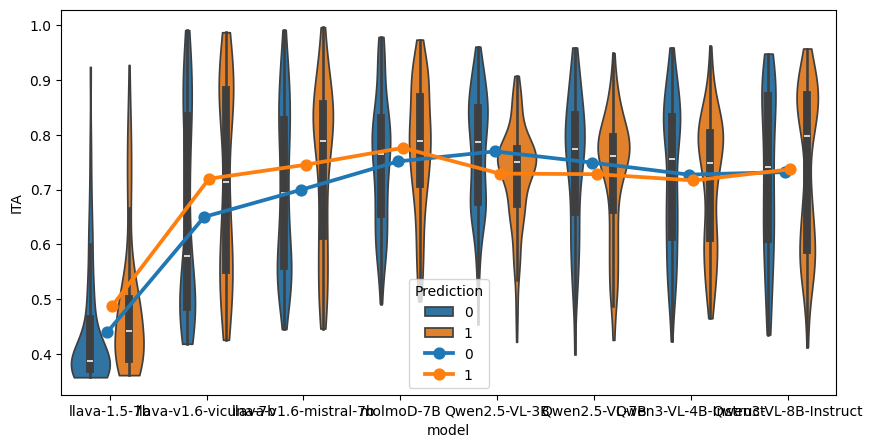

In [142]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench',
]

embedding_col = '0'
current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'

fig,ax = plt.subplots(1,1,figsize=(10,5))
ax = [ax]
plot_df = []

for idx, model_name in enumerate(model_ls):
    for ds_name in ds_names:
        if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
            pass
        elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
            pass
        elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
            pass
        else:
            # read dataset
            df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
            if ds_name=='MATE':
                df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]
            # create prediction correct or not column
            df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]

        embedding_cols = [c for c in df.columns if c.isdigit()]
        embedding_cols = embedding_cols[0]
        
        # plot x and y
        df_pivot = (
            df.query("`Mean over` in ['All tokens','Img tokens','Text tokens']")
              .pivot(index="Unnamed: 0", columns="Mean over", values=embedding_cols)
              .reset_index(drop=True)
        )
                
        y = df_pivot.mean(axis=1) / df_pivot.max(axis=1)
        
        # plot x and y
        x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
        
        plot_df_ds = pd.DataFrame({
            'Prediction':x,
            'ITA':y,
            # 'hue': hue,
            'model': [model_name]*len(x),
            'ds': [ds_name]*len(x)
        })
        
        plot_df = plot_df + [plot_df_ds]
        # total_df = total_df + [plot_df_ds]
plot_df = pd.concat(plot_df)
                
                


########### PLOT
b = sns.violinplot(
    data=plot_df,
    x='model',
    y="ITA",

    hue='Prediction',
    ax=ax[i],
    cut=0
)            

sns.pointplot(
    data=plot_df,
    x='model',
    y="ITA",
    estimator='mean',
    hue='Prediction',
    ax=ax[i],
    dodge=True,
    errorbar=None,
    
)

# fig.savefig(
#     "./../Figures/eRank_gap_quantile.png",
#     dpi=300,
#     # transparent=True,
#     bbox_inches="tight"
# )

In [139]:
df['outputwImg'].iloc[5]

'user\n QUESTION: Which one picture follows the same pattern or rule established by the previous pictures?\nOPTIONS:\n0: Picture A\n1: Picture B\n2: Picture C\n3: Picture D\n\nAnswer with the correct option from 0 to 3. Only provide the numeric and nothing else \n\n\nAnswer: \nassistant\n3'

In [ ]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench',
]

embedding_col = '0'
current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'

fig,ax = plt.subplots(1,1,figsize=(10,5))
ax = [ax]
plot_df = []

for idx, model_name in enumerate(model_ls):
    for ds_name in ds_names:
        if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
            pass
        elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
            pass
        elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
            pass
        else:
            # read dataset
            df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
            if ds_name=='MATE':
                df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]
            # create prediction correct or not column
            df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]

        embedding_cols = [c for c in df.columns if c.isdigit()]
        embedding_cols = embedding_cols[-1]
        
        # plot x and y
        df_pivot = (
            df.query("`Mean over` in ['All tokens','Img tokens','Text tokens']")
              .pivot(index="Unnamed: 0", columns="Mean over", values=embedding_cols)
              .reset_index(drop=True)
        )
                
        y = df_pivot.mean(axis=1) / df_pivot.max(axis=1)
        
        # plot x and y
        x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
        
        plot_df_ds = pd.DataFrame({
            'Prediction':x,
            'ITA':y,
            # 'hue': hue,
            'model': [model_name]*len(x),
            'ds': [ds_name]*len(x)
        })
        
        plot_df = plot_df + [plot_df_ds]
        # total_df = total_df + [plot_df_ds]
plot_df = pd.concat(plot_df)
                
                


########### PLOT
b = sns.scatterplot(
    data=plot_df,
    x='model',
    y="ITA",
    hue='Prediction',
    ax=ax[i],
)            


# fig.savefig(
#     "./../Figures/eRank_gap_quantile.png",
#     dpi=300,
#     # transparent=True,
#     bbox_inches="tight"
# )

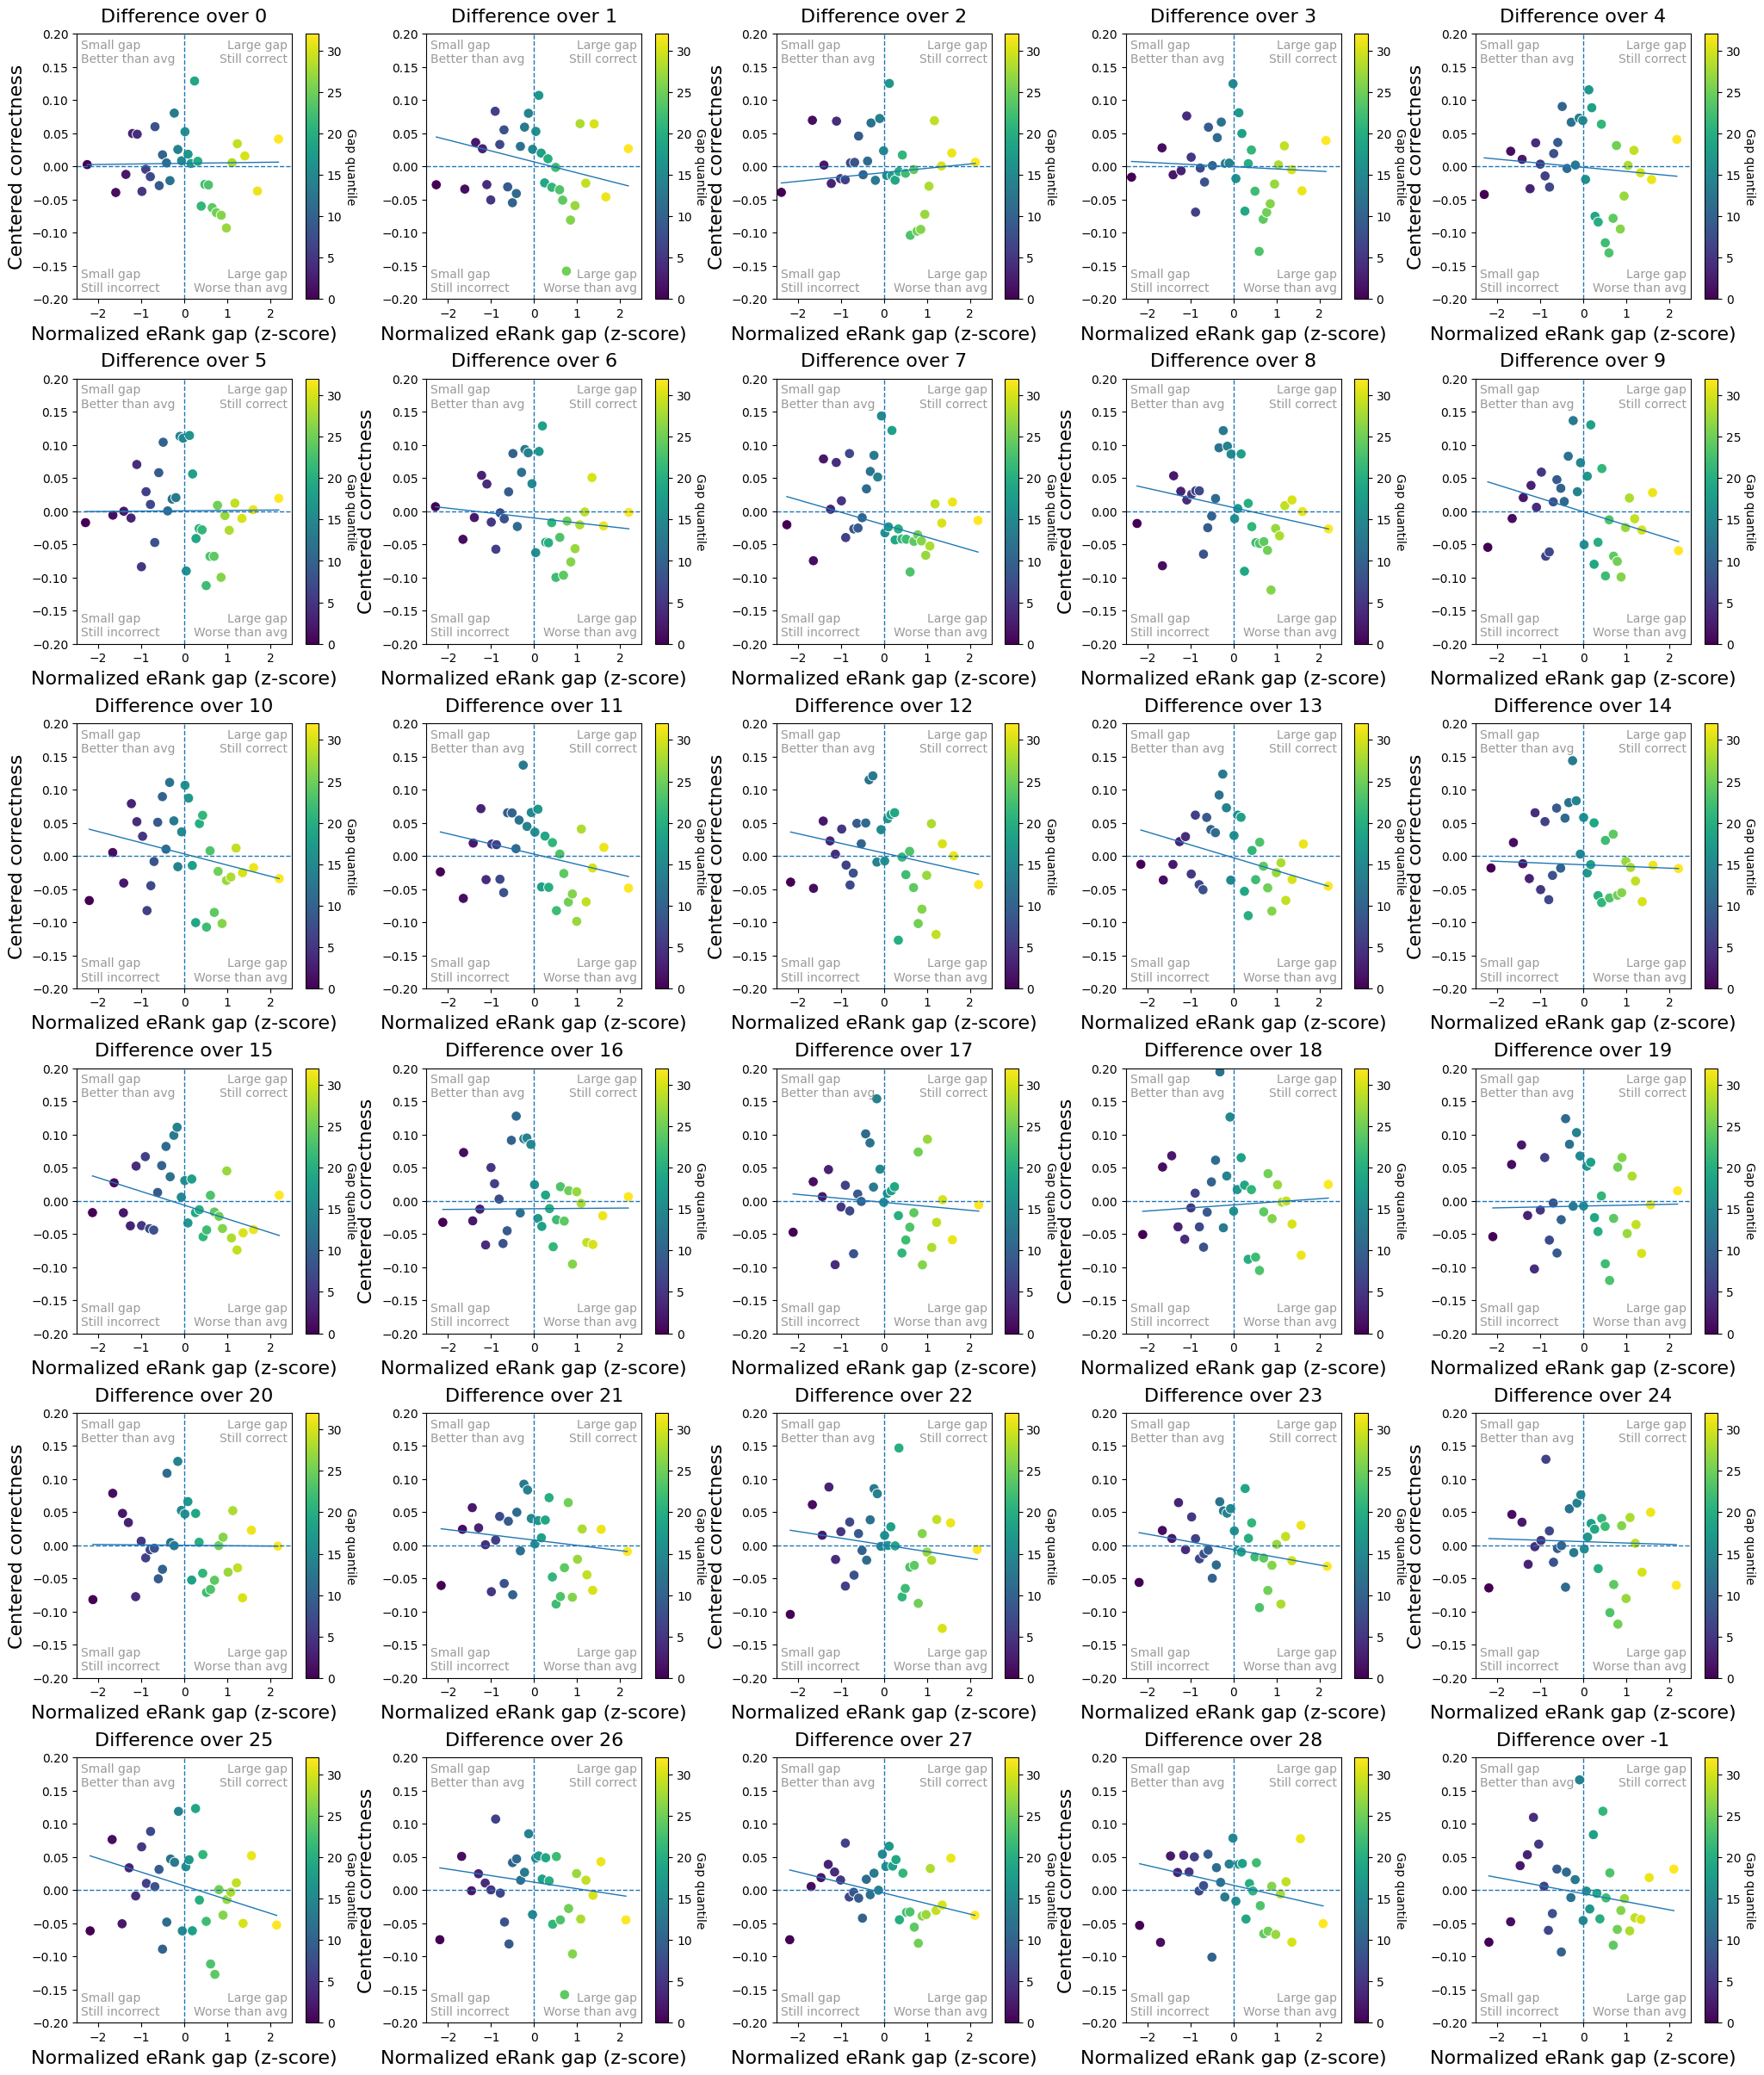

In [326]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

# fig, axes = plt.subplots(nrows=len(model_ls), ncols=1, figsize=(7.5, 20))
# axes = axes.flatten()
lastn=-1
# lastn = int(3*len(embedding_cols)/4)
lastn = 0
# lastns = [0, 5, 11, 15, 20, -5, -3, -1]
lastns = list(range(0,29))+[-1]
# lastns = [0]
# title_mapper = {
#     0: '1st layer',
#     5: '5th layer',
#     11: '11th layer',
#     15: '15th layer',
#     20: '20th layer',
#     -5: '5th last layer',
#     -3: '3rd last layer',
#     -1: 'Last layer',
# }

fig,ax = plt.subplots(6,5,figsize=(25,30))
ax = ax.flatten()

for i, lastn in enumerate(lastns):
    total_df = []
    for idx, model_name in enumerate(model_ls):
        plot_df = []
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
                pass
            elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
                pass
            elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
    
                if ds_name=='MATE':
                    df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]
    
                # create prediction correct or not column
                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                
                embedding_cols = [c for c in df.columns if c.isdigit()]
                
                embedding_cols = embedding_cols[lastn]
                
                # plot x and y
                # print(embedding_cols, len(embedding_cols))
                
                y = df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                    df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy()
                # y = np.abs(y)
                
                # plot x and y
                x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
                
                plot_df_ds = pd.DataFrame({
                    'Prediction':x,
                    'eRank_diff':y,
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
                total_df = total_df + [plot_df_ds]
        plot_df = pd.concat(plot_df)
    
    total_df = pd.concat(total_df)
    
    total_df_ = total_df.copy()
    
    # z-score eRank_diff within each (dataset, model)
    total_df_["gap_z"] = (
        total_df_.groupby(["ds", "model"])["eRank_diff"]
          .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )
    
    # center correctness (Prediction) within each (dataset, model)
    total_df_["pred_c"] = (
        total_df_.groupby(["ds", "model"])["Prediction"]
          .transform(lambda x: x - x.mean())
    )
    
    
    # bin gap_z into quantiles (globally is fine after normalization)
    total_df_["gap_bin"] = pd.qcut(total_df_["gap_z"], q=33, labels=False)
    
    plot_df_ = (
        total_df_.groupby("gap_bin")
          .agg(
              gap_z_mean=("gap_z", "mean"),
              pred_mean=("pred_c", "mean"),
              n=("pred_c", "size"),
          )
          .reset_index()
    )

    ########### PLOT
    b = sns.scatterplot(
        data=plot_df_,
        x="gap_z_mean",
        y="pred_mean",
        hue="gap_bin",
        palette="viridis",
        s=70,
        ax=ax[i],
        # legend="brief"
        legend=False      # ⟵ turn off legend
    )
    
    # Add colorbar manually
    norm = plt.Normalize(
        plot_df_["gap_bin"].min(),
        plot_df_["gap_bin"].max()
    )
    
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    
    cbar = plt.colorbar(sm, ax=ax[i])
    cbar.set_label("Gap quantile", rotation=270, labelpad=12)
    # cbar.set_ticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
        
    # quadrant annotations (subtle)
    kw = dict(fontsize=10, color="gray", alpha=0.8)

    b.text(0.98, 0.98, "Large gap\nStill correct",
               transform=b.transAxes, va="top", ha="right", **kw)
    b.text(0.02, 0.98, "Small gap\nBetter than avg",
               transform=b.transAxes, va="top", ha="left", **kw)
    b.text(0.02, 0.02, "Small gap\nStill incorrect",
               transform=b.transAxes, va="bottom", ha="left", **kw)
    b.text(0.98, 0.02, "Large gap\nWorse than avg",
               transform=b.transAxes, va="bottom", ha="right", **kw)

    b.axhline(0, linestyle="--", linewidth=1)
    b.axvline(0, linestyle="--", linewidth=1)

    import numpy as np
    from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor
    
    # x, y as 1D arrays
    x = np.asarray(plot_df_['gap_z_mean'])
    y = np.asarray(plot_df_['pred_mean'])
    
    # sklearn expects 2D X
    X = x.reshape(-1, 1)
    
    regressor = HuberRegressor(epsilon=1)
    # regressor = RANSACRegressor(random_state=42)
    # regressor = TheilSenRegressor(random_state=42)
    
    
    regressor.fit(X, y)
    
    # smooth line for plotting
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = regressor.predict(x_fit.reshape(-1, 1))

    sns.regplot(
        y=y_fit,
        x=x_fit,
        ci=None,
        scatter=False,
        ax=b,
        line_kws={"lw": 1}
    )
    
    b.set_xlabel("Normalized eRank gap (z-score)", labelpad=5, fontsize=fontsize)
    
    if i%2==0:
        b.set_ylabel("Centered correctness", labelpad=5, fontsize=fontsize)
    else:
        b.set_ylabel("")
    b.set(xlim=(-2.5,2.5), ylim=(-0.2, 0.2))
    b.set_title(
       # "Within-dataset normalized gap vs outcome",
        f"Difference over {lastn}", #title_mapper[
        pad=10,
        fontsize=fontsize,
    )
    
        
    # b.set_xticklabels(
    #     b.get_xticklabels(), 
    #     fontsize=fontsize_minor,
    #     rotation_mode="anchor",
    # )
    # b.set_yticklabels(
    #     b.get_yticklabels(), 
    #     fontsize=fontsize_minor,
    # )

    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    
                
    # b.legend(
    #     loc=(0.05,0.8),
    #     ncols=1,
    #     frameon=False, 
    #     fontsize=fontsize_minor,
    # )
    
    # b.legend_.remove()
# sns.despine(top=True, right=True)

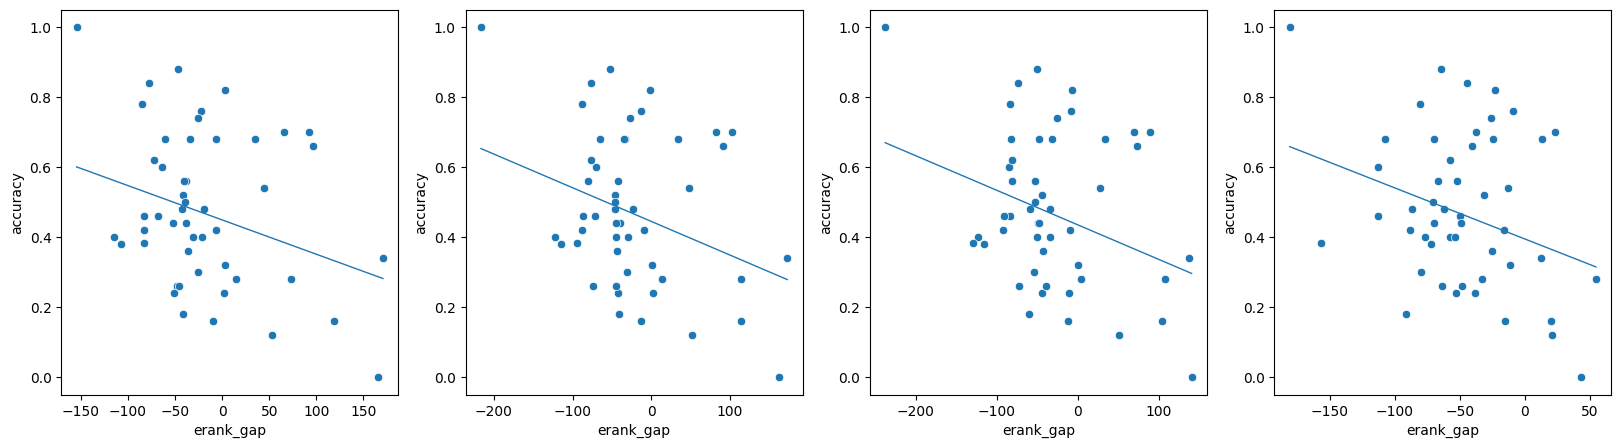

In [85]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
# axes = axes.flatten()
# axes=[axes]
for idx, lastn in enumerate([-7,-5,-3, -1]):
    plot_df = []
    for model_name in model_ls:
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
                pass
            elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
                pass
            elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
                
                # create prediction correct or not column
                if ds_name=='MATE':
                    df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]

                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                embedding_cols = [c for c in df.columns if c.isdigit()]
                embedding_cols = embedding_cols[lastn]
                
                # plot x and y
                x = [df[df['Mean over']=='Text tokens']['verdict'].to_numpy().sum()/len(df[df['Mean over']=='Text tokens'])]
                    # y = [np.linalg.norm(df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())]
                # y = np.sum((
                #         df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                #         df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2
                #     )/len(embedding_cols*len(df[df['Mean over']=='Text tokens']))
                # y = [np.sqrt(y)]
                
                y = np.sum(df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                        df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy()
                    )/len(df[df['Mean over']=='Text tokens'])
                
                y = [y]
                
                plot_df_ds = pd.DataFrame({
                    'accuracy':x,
                    'erank_gap':y,
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                plot_df = plot_df + [plot_df_ds]  
                
    plot_df = pd.concat(plot_df)
    
    b = sns.scatterplot(
        data=plot_df,
        y='accuracy',
        x='erank_gap',
        # hue='Prediction',
        ax=axes[idx],
    )

    import numpy as np
    from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor
    
    # x, y as 1D arrays
    x = np.asarray(plot_df['erank_gap'])
    y = np.asarray(plot_df['accuracy'])
    
    # sklearn expects 2D X
    X = x.reshape(-1, 1)
    
    regressor = HuberRegressor(fit_intercept=True)
    # regressor = RANSACRegressor(random_state=42)
    # regressor = TheilSenRegressor(random_state=42)
    
    
    regressor.fit(X, y)
    
    # smooth line for plotting
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = regressor.predict(x_fit.reshape(-1, 1))

    sns.regplot(
        y=y_fit,
        x=x_fit,
        ci=None,
        scatter=False,
        ax=b,
        line_kws={"lw": 1}
    )

# b.set_title(model_name)

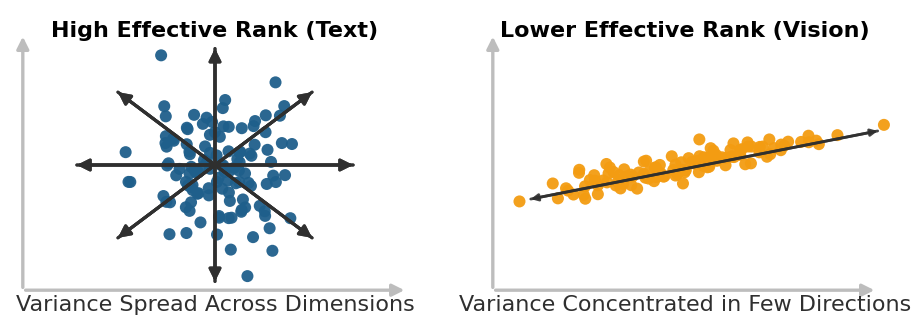

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyArrowPatch, Arc

# ----------------------------
# Data (replace with your own if you want)
# ----------------------------
rng = np.random.default_rng(0)

# Left: "high eRank" cloud (roughly isotropic)
n1 = 120
x1 = rng.normal(0, 0.6, n1)
y1 = rng.normal(0, 0.6, n1)

# Right: "low eRank" cigar (anisotropic, mostly along one direction)
n2 = 120
t = rng.normal(0, 0.8, n2)
x2 = 1.6 * t + 0.25 * rng.normal(0, 1.0, n2)
y2 = 0.35 * t + 0.12 * rng.normal(0, 1.0, n2)

# Colors (close to the figure; tweak if you like)
BLUE = "#1f5f8b"
ORANGE = "#f39c12"
DARK = "#2f2f2f"
GREY = "#bdbdbd"

# ----------------------------
# Helper: draw axis with arrow head
# ----------------------------
def arrow_axis(ax, start, end, color=GREY, lw=2.2, head=14, alpha=1.0):
    ax.add_patch(FancyArrowPatch(
        posA=start, posB=end,
        arrowstyle='-|>',
        mutation_scale=head,
        linewidth=lw,
        color=color,
        alpha=alpha
    ))

# def centered_arrow(ax, center, vec, color=DARK, lw=2.4, head=16, alpha=1.0):
#     """Arrow centered at 'center' going in direction 'vec' (both ways)."""
#     cx, cy = center
#     vx, vy = vec
#     ax.add_patch(FancyArrowPatch(
#         posA=(cx - vx, cy - vy), posB=(cx + vx, cy + vy),
#         arrowstyle='-|>',
#         mutation_scale=head,
#         linewidth=lw,
#         color=color,
#         alpha=alpha
#     ))

from matplotlib.patches import FancyArrowPatch

def centered_arrow(ax, center, vec, color=DARK, lw=2.4, head=16, alpha=1.0):
    """
    Draw a double-headed arrow centered at `center`,
    oriented along `vec`.
    """
    cx, cy = center
    vx, vy = vec

    p0 = (cx - vx, cy - vy)
    p1 = (cx + vx, cy + vy)

    # forward arrow
    ax.add_patch(FancyArrowPatch(
        posA=p0, posB=p1,
        arrowstyle='-|>',
        mutation_scale=head,
        linewidth=lw,
        color=color,
        alpha=alpha
    ))

    # backward arrow (second head)
    ax.add_patch(FancyArrowPatch(
        posA=p1, posB=p0,
        arrowstyle='-|>',
        mutation_scale=head,
        linewidth=lw,
        color=color,
        alpha=alpha
    ))


# ----------------------------
# Figure layout
# ----------------------------
fig = plt.figure(figsize=(10, 5), facecolor="white")

# Two panels (manual positioning gives you "paper figure" control)
axL = fig.add_axes([0.06, 0.16, 0.41, 0.62])  # [left, bottom, width, height]
axR = fig.add_axes([0.53, 0.16, 0.41, 0.62])

for ax in (axL, axR):
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.6, 2.6)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

# ----------------------------
# LEFT PANEL: "High effective rank"
# ----------------------------
axL.scatter(x1, y1, s=75, color=BLUE, edgecolor="none", alpha=0.95)

# Axes (light grey)
arrow_axis(axL, (-3.0, -2.1), (3.0, -2.1), color=GREY, lw=2.4, head=18)
arrow_axis(axL, (-3.0, -2.1), (-3.0, 2.2), color=GREY, lw=2.4, head=18)

# Multi-direction "variance spread" arrows (dark)
center = (0.0, 0.0)
vecs = [
    (2.2, 0.0), (-2.2, 0.0), (0.0, 2.0), (0.0, -2.0),
    (1.55, 1.25), (-1.55, 1.25), (1.55, -1.25), (-1.55, -1.25)
]
for vx, vy in vecs:
    centered_arrow(axL, center, (vx, vy), color=DARK, lw=2.2, head=18, alpha=0.9)

# Titles and text
axL.text(0.5, 0.9, "High Effective Rank (Text)",
         transform=axL.transAxes, ha="center", va="bottom",
         fontsize=fontsize, fontweight="bold")

# axL.text(0.55, 0.07, "Variance Spread\nAcross Dimensions",
#          transform=axL.transAxes, ha="center", va="center",
#          fontsize=16, color=DARK)

axL.text(0.5, 0.08, "Variance Spread Across Dimensions",
         transform=axL.transAxes, ha="center", va="top",
         fontsize=16, color=DARK)

# ----------------------------
# RIGHT PANEL: "Lower effective rank"
# ----------------------------
axR.scatter(x2, y2, s=75, color=ORANGE, edgecolor="none", alpha=0.95)

# Axes (light grey)
arrow_axis(axR, (-3.0, -2.1), (3.0, -2.1), color=GREY, lw=2.4, head=18)
arrow_axis(axR, (-3.0, -2.1), (-3.0, 2.2), color=GREY, lw=2.4, head=18)

# One dominant direction arrow (dark, along the "cigar")
# choose a direction roughly matching the data slope
center2 = (.3, -0)
centered_arrow(axR, center2, (2.75, 0.58), color=DARK, lw=2.0, head=10, alpha=0.9)

# Callout annotation

axR.text(0.5, 0.9, "Lower Effective Rank (Vision)",
         transform=axR.transAxes, ha="center", va="bottom",
         fontsize=fontsize, fontweight="bold", )

axR.text(0.5, 0.08, "Variance Concentrated in Few Directions",
         transform=axR.transAxes, ha="center", va="top",
         fontsize=16, color=DARK)

plt.show()

fig.savefig(
    "./../Figures/eRank_illustration.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)